# Exploración y descripción del Dataset: OASIS Cross-Sectional

El conjunto de datos utilizado proviene de la Open Access Series of Imaging Studies (OASIS), una base ampliamente utilizada en investigación sobre demencia y Alzheimer. Este dataset contiene imágenes de resonancia magnética cerebral estructural (T1-weighted MPRAGE) en formato NIfTI (.hdr/.img), organizadas por sujeto. En particular, el subconjunto analizado (disc1) incluye aproximadamente 20 sujetos (OAS1_0001 a OAS1_0020), aunque el repositorio completo contiene un total de 12 discos. Para cada sujeto se dispone de múltiples versiones de las imágenes: adquisiciones crudas (RAW), imágenes procesadas y promediadas (PROCESSED/SUBJ), registros en el espacio estándar Talairach (PROCESSED/T88) y segmentaciones de tejidos (FSL_SEG) que distinguen materia gris, materia blanca y líquido cefalorraquídeo. Las imágenes presentan una resolución típica de 256 × 256 × 160 vóxeles y están acompañadas de metadatos clínicos y demográficos relevantes, como edad, sexo, CDR (Clinical Dementia Rating), volumen intracraneal estimado (eTIV), volumen cerebral normalizado (nWBV) y factor de escala (ASF).


## 0. Importaciones

In [18]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import glob, os
import pandas as pd
from scipy import stats
from dotenv import load_dotenv

env_path = os.path.join(os.getcwd(), '.env')
if not os.path.isfile(env_path):
    env_path = os.path.join(os.getcwd(), 'Proyecto-Imagenes', '.env')

load_dotenv(env_path, override=True)

DATASET_ROOT = os.getenv('DATASET_ROOT')

if not DATASET_ROOT:
    raise ValueError("DATASET_ROOT no está definido en el archivo .env")
    
print(f"Dataset root: {DATASET_ROOT}")

Dataset root: C:\Users\sebas\Downloads\oasis_cross-sectional_disc1


## 1. Visualización de las Imágenes de un sujeto 

### 1.1 Visualización de las 4 Imágenes RAW de un sujeto 

En el dataset OASIS, cada sesión de escaneo incluye **4 tomas a un sujeto repetidas** (mpr-1, mpr-2, mpr-3, mpr-4). Estas repeticiones se realizan dentro de una misma sesión para incrementar la relación señal-ruido mediante promediado posterior.

Estas 4 tomas: 

- Son volúmenes 3D sin procesar, capturados consecutivamente en la misma sesión
- Cada volumen tiene dimensiones de 256 × 256 × 128 vóxeles con resolución de 1.0 × 1.0 × 1.25 mm
- Contienen ruido inherente al proceso de adquisición MRI y movimiento si el paciente se movió entre escaneos

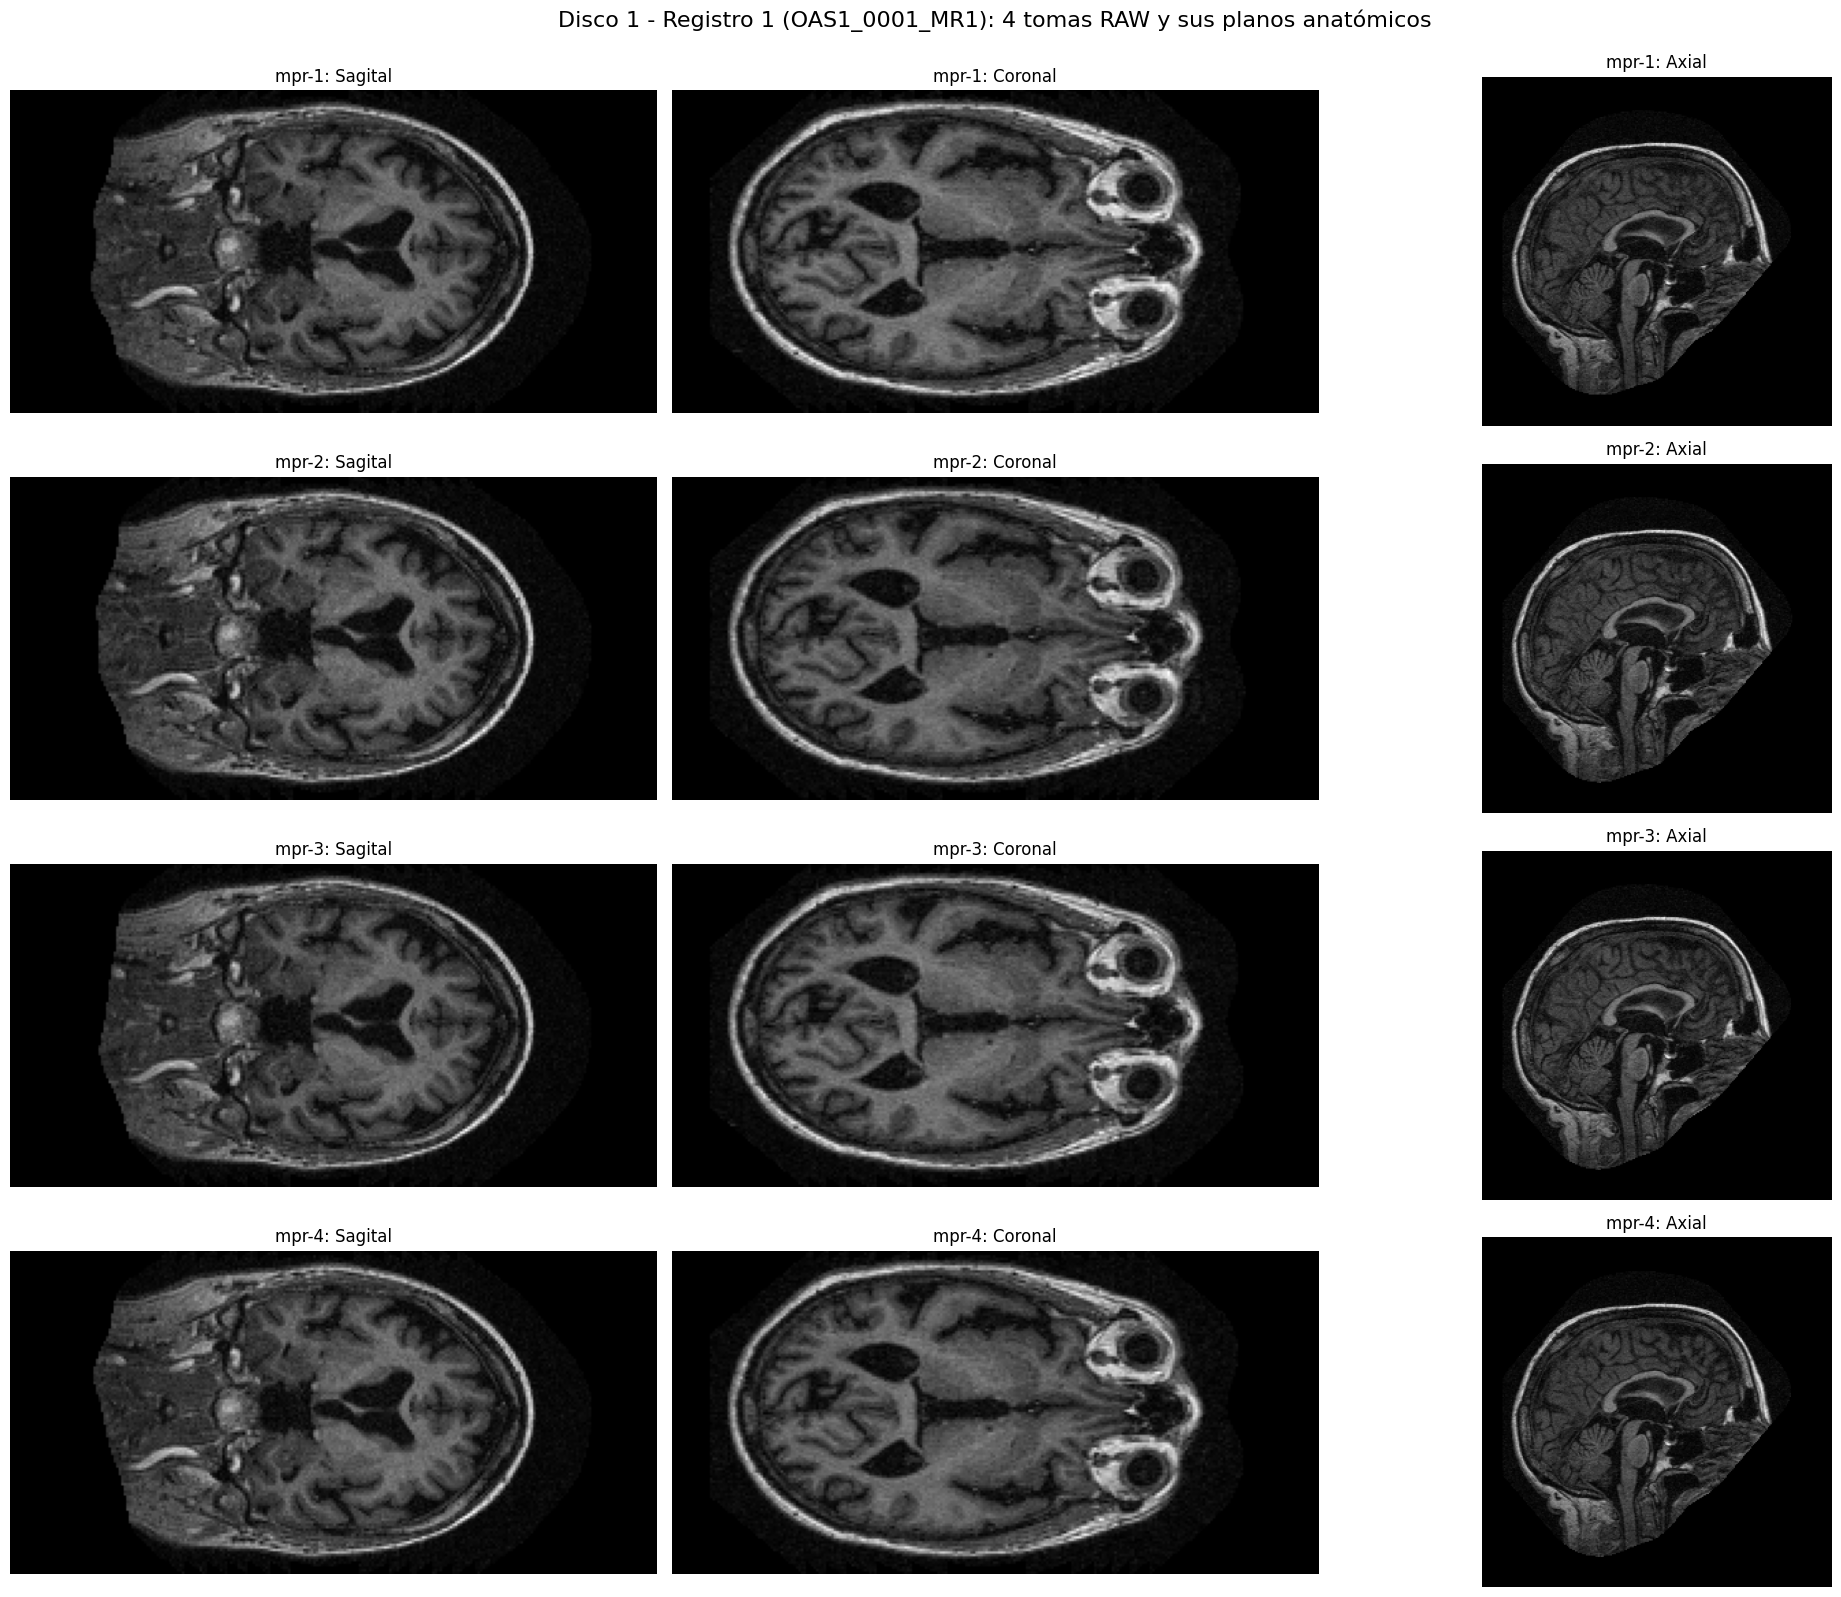


Información de cada volumen RAW:
Shape del volumen: (256, 256, 128)
Rango de intensidades: [0.0, 4095.0]
Resolución vóxel (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.25), np.float32(0.0))


In [28]:
BASE = os.path.join(DATASET_ROOT, 'OAS1_0001_MR1', 'RAW')

raw_files = ['OAS1_0001_MR1_mpr-1_anon.hdr', 
             'OAS1_0001_MR1_mpr-2_anon.hdr',
             'OAS1_0001_MR1_mpr-3_anon.hdr', 
             'OAS1_0001_MR1_mpr-4_anon.hdr']

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Disco 1 - Registro 1 (OAS1_0001_MR1): 4 tomas RAW y sus planos anatómicos', fontsize=16, y=0.995)

for idx, filename in enumerate(raw_files):
    hdr_path = os.path.join(BASE, filename)
    img = nib.load(hdr_path)
    data = np.squeeze(img.get_fdata())
    
    cx, cy, cz = data.shape[0]//2, data.shape[1]//2, data.shape[2]//2
    
    # Plano Sagital
    ax1 = plt.subplot(4, 3, idx*3 + 1)
    ax1.imshow(np.squeeze(data[cx, :, :]).T, cmap='gray', origin='lower')
    ax1.set_title(f'mpr-{idx+1}: Sagital')
    ax1.axis('off')
    
    # Plano Coronal
    ax2 = plt.subplot(4, 3, idx*3 + 2)
    ax2.imshow(np.squeeze(data[:, cy, :]).T, cmap='gray', origin='lower')
    ax2.set_title(f'mpr-{idx+1}: Coronal')
    ax2.axis('off')
    
    # Plano Axial
    ax3 = plt.subplot(4, 3, idx*3 + 3)
    ax3.imshow(np.squeeze(data[:, :, cz]).T, cmap='gray', origin='lower')
    ax3.set_title(f'mpr-{idx+1}: Axial')
    ax3.axis('off')

plt.tight_layout()
plt.show()

img = nib.load(os.path.join(BASE, raw_files[0]))
data = np.squeeze(img.get_fdata())
print(f"\nInformación de cada volumen RAW:")
print(f"Shape del volumen: {data.shape}")
print(f"Rango de intensidades: [{data.min():.1f}, {data.max():.1f}]")
print(f"Resolución vóxel (mm): {img.header.get_zooms()}")

Se cargó el volumen MRI del sujeto OAS1_0001 en su versión RAW para explorar los datos en su versión original. El volumen tiene dimensiones de 256 × 256 × 128 vóxeles, con una resolución espacial de 1.0 × 1.0 × 1.25 mm por vóxel, y un rango de intensidades de 0 a 4095 debido a su codificación en 12 bits. Se visualizaron los tres planos anatómicos estándar para sus 4 tomas: sagital, coronal y axial, correspondientes a cortes perpendiculares a cada uno de los ejes espaciales del volumen. Esta visualización permite obtener información relevante del dato, identificar la orientación en la que se encuentran las imágenes y obtener una primera impresión visual de la calidad del dataset.

### 1.2 Visualización Imagen Promedio

La imagen es el resultado del promediado de las 4 adquisiciones RAW. Esta imagen logra que el ruido aleatorio se cancele al promediar múltiples adquisiciones, convirtiendo las 4 en una imagen más nítida con menos ruido granular y bordes más definidos.


Imagen Promedio:
Shape: (256, 256, 160)
Rango de intensidades: [0.0, 3866.0]
Resolución vóxel (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(0.0))


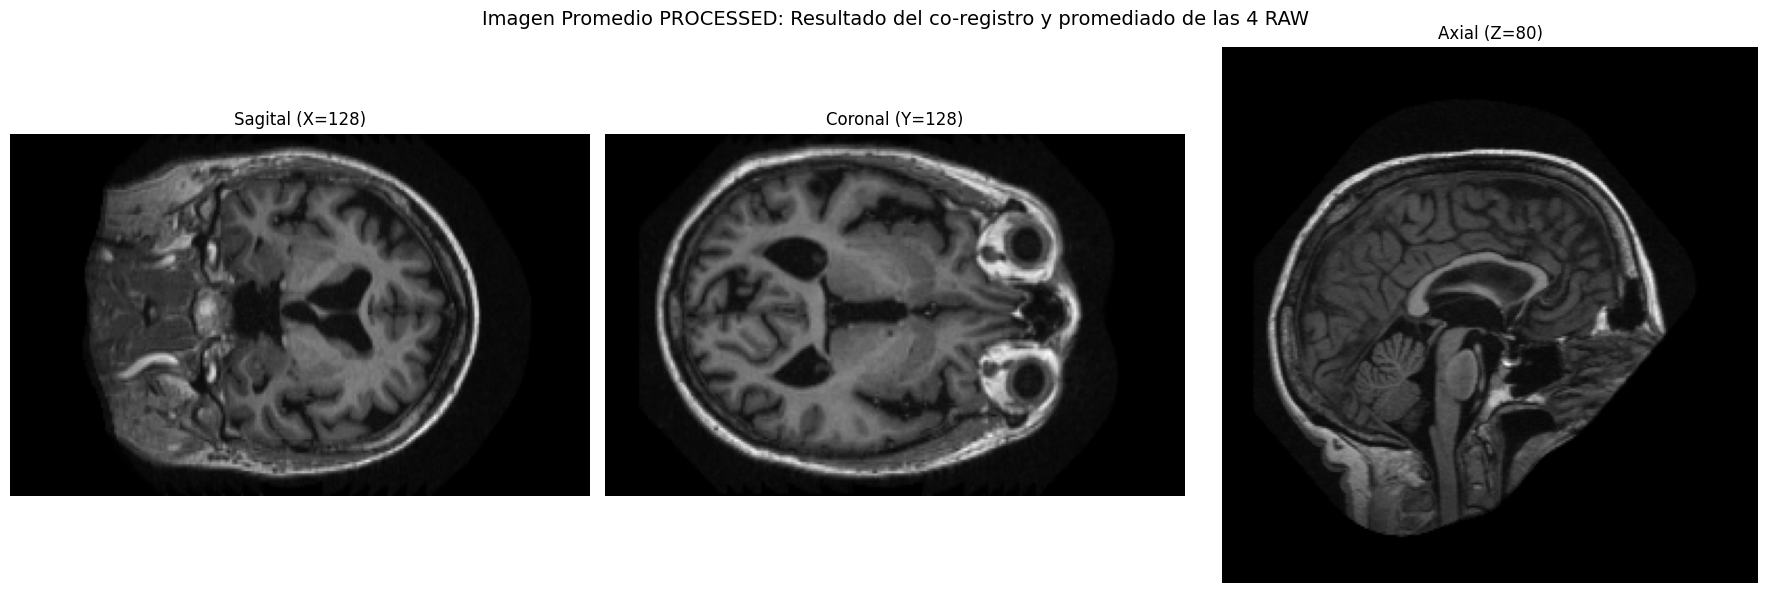

In [51]:
processed_path = os.path.join(DATASET_ROOT, 'OAS1_0001_MR1', 'PROCESSED', 'MPRAGE', 'SUBJ_111', 
                               'OAS1_0001_MR1_mpr_n4_anon_sbj_111.hdr')

img_avg = nib.load(processed_path)
data_avg = np.squeeze(img_avg.get_fdata())

print(f"Imagen Promedio:")
print(f"Shape: {data_avg.shape}")
print(f"Rango de intensidades: [{data_avg.min():.1f}, {data_avg.max():.1f}]")
print(f"Resolución vóxel (mm): {img_avg.header.get_zooms()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Imagen Promedio PROCESSED: Resultado del co-registro y promediado de las 4 RAW', fontsize=14)

cx, cy, cz = data_avg.shape[0]//2, data_avg.shape[1]//2, data_avg.shape[2]//2

axes[0].imshow(data_avg[cx, :, :].T, cmap='gray', origin='lower')
axes[0].set_title(f'Sagital (X={cx})')
axes[0].axis('off')

axes[1].imshow(data_avg[:, cy, :].T, cmap='gray', origin='lower')
axes[1].set_title(f'Coronal (Y={cy})')
axes[1].axis('off')

axes[2].imshow(data_avg[:, :, cz].T, cmap='gray', origin='lower')
axes[2].set_title(f'Axial (Z={cz})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 1.3 Visualización de Procesamiento

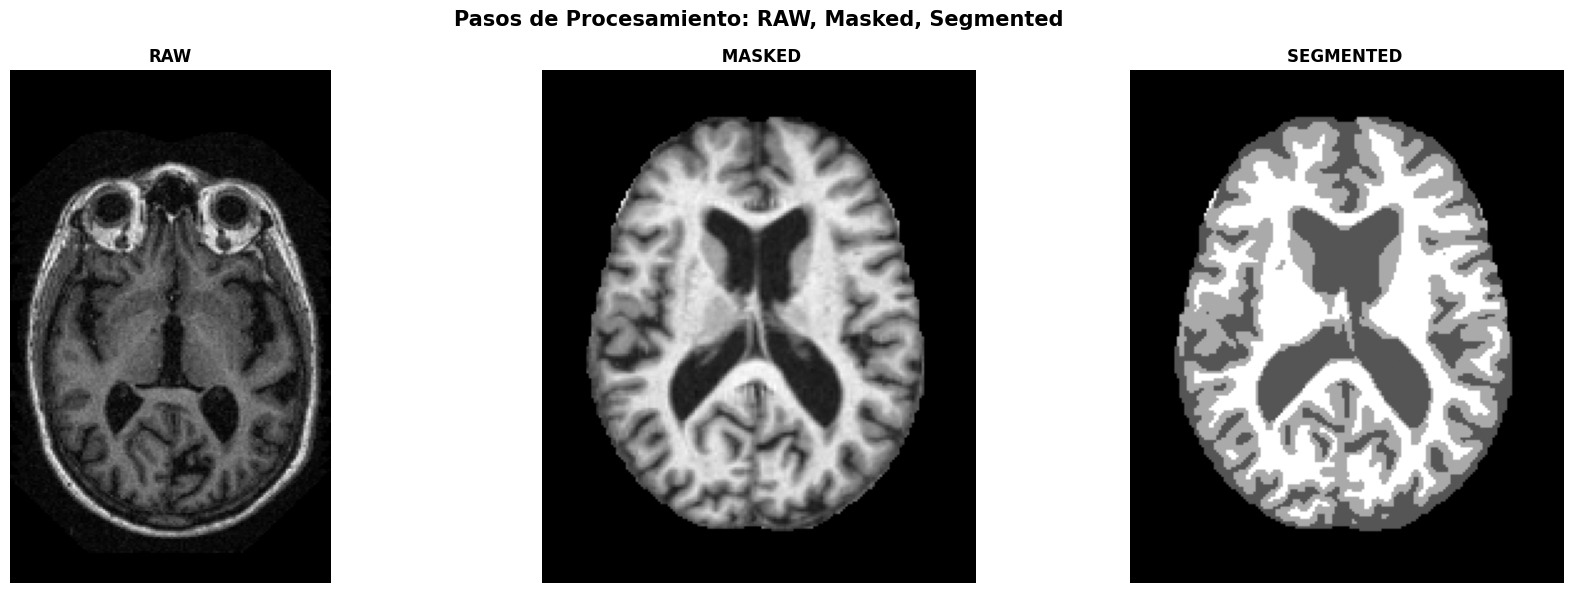

RAW shape: (256, 256, 128) | Rango de píxeles: [0, 4095]
MASKED shape: (176, 208, 176) | Rango de píxeles: [0, 3126]
SEGMENTED shape: (176, 208, 176) | Clases únicas de tejido: [0. 1. 2. 3.]


In [46]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# (Asegúrate de definir DATASET_ROOT antes)
BASE = os.path.join(DATASET_ROOT, 'OAS1_0001_MR1')

raw_path = os.path.join(BASE, 'RAW', 'OAS1_0001_MR1_mpr-1_anon.hdr')
masked_path = os.path.join(BASE, 'PROCESSED', 'MPRAGE', 'T88_111', 
                           'OAS1_0001_MR1_mpr_n4_anon_111_t88_masked_gfc.hdr')
segmented_path = os.path.join(BASE, 'FSL_SEG', 
                              'OAS1_0001_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg.hdr')

img_raw = nib.load(raw_path)
img_masked = nib.load(masked_path)
img_seg = nib.load(segmented_path)

data_raw = np.squeeze(img_raw.get_fdata())
data_masked = np.squeeze(img_masked.get_fdata())
data_seg = np.squeeze(img_seg.get_fdata())

# Plano Axial Procesadas
slice_idx_t88 = data_masked.shape[2] // 2 
masked_slice = np.squeeze(data_masked[:, :, slice_idx_t88]).T
seg_slice = np.squeeze(data_seg[:, :, slice_idx_t88]).T

# Plano Axial RAW
slice_idx_raw = data_raw.shape[1] // 2  
raw_slice = np.squeeze(data_raw[:, slice_idx_raw, :])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Pasos de Procesamiento: RAW, Masked, Segmented', fontsize=15, fontweight='bold')


axes[0].imshow(raw_slice, cmap='gray', origin='lower', aspect=0.8)
axes[0].set_title('RAW', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(masked_slice, cmap='gray', origin='lower')
axes[1].set_title(' MASKED', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(seg_slice, cmap='gray', origin='lower', vmin=0, vmax=3)
axes[2].set_title('SEGMENTED ', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"RAW shape: {data_raw.shape} | Rango de píxeles: [{data_raw.min():.0f}, {data_raw.max():.0f}]")
print(f"MASKED shape: {data_masked.shape} | Rango de píxeles: [{data_masked.min():.0f}, {data_masked.max():.0f}]")
print(f"SEGMENTED shape: {data_seg.shape} | Clases únicas de tejido: {np.unique(data_seg)}")

Aqui podemos ver los tres estados del volumen MRI del sujeto OAS1_0001 según el pipeline de procesamiento del dataset OASIS. La imagen RAW corresponde a la adquisición original sin ningún procesamiento, conteniendo el cráneo completo y tejidos extracraneales junto con ruido inherente de la adquisición. La imagen MASKED es el resultado de aplicar skull stripping sobre la imagen promediada y registrarla al espacio estándar de Talairach (T88), eliminando los tejidos no cerebrales y garantizando una alineación anatómica consistente entre sujetos. Por ultimo, La imagen SEGMENTED es el producto de la segmentación automática con FSL, donde cada vóxel se clasifica en materia gris, materia blanca o líquido cefalorraquídeo.

## 2. Entendimiento del CSV

In [24]:
csv_path = 'oasis_cross-sectional-5708aa0a98d82080.xlsx' 
df = pd.read_excel(csv_path)

df.head(10)

,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN
5,OAS1_0006_MR1,F,R,24,NaN,NaN,NaN,NaN,1131,0.862,1.551,NaN
6,OAS1_0007_MR1,M,R,21,NaN,NaN,NaN,NaN,1516,0.830,1.157,NaN
7,OAS1_0009_MR1,F,R,20,NaN,NaN,NaN,NaN,1505,0.843,1.166,NaN
8,OAS1_0010_MR1,M,R,74,5.0,2.0,30.0,0.0,1636,0.689,1.073,NaN
9,OAS1_0011_MR1,F,R,52,3.0,2.0,30.0,0.0,1321,0.827,1.329,NaN


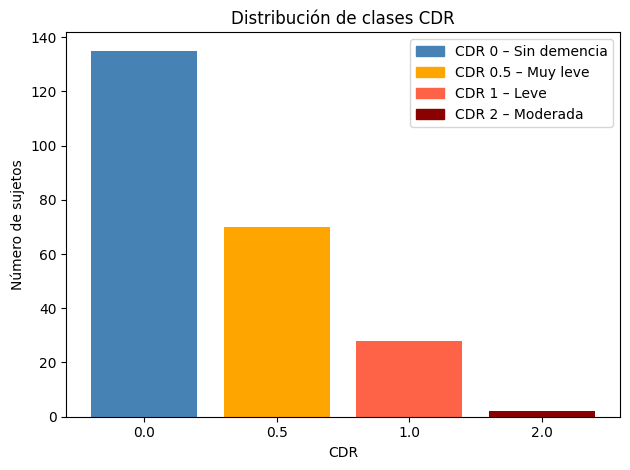

In [ ]:
df_cdr = df.dropna(subset=['CDR'])
cdr_counts = df_cdr['CDR'].value_counts().sort_index()
colores = ['steelblue', 'orange', 'tomato', 'darkred']
etiquetas = {0.0: 'CDR 0 – Sin demencia', 0.5: 'CDR 0.5 – Muy leve', 1.0: 'CDR 1 – Leve', 2.0: 'CDR 2 – Moderada'}
bars = plt.bar([str(k) for k in cdr_counts.index],cdr_counts.values,color=colores[:len(cdr_counts)])
patches = [mpatches.Patch(color=colores[i], label=etiquetas[k]) for i, k in enumerate(cdr_counts.index)]

plt.legend(handles=patches, loc='upper right')
plt.title('Distribución de clases CDR')
plt.xlabel('CDR')
plt.ylabel('Número de sujetos')
plt.tight_layout()
plt.show()

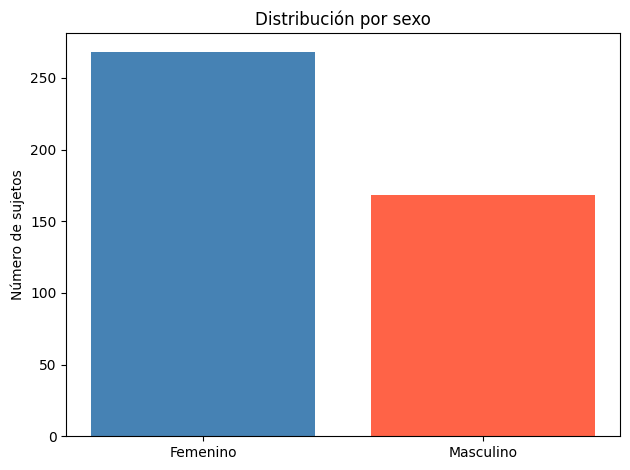

In [25]:
counts = df['M/F'].value_counts()

plt.bar(['Femenino', 'Masculino'], [counts.get('F', 0), counts.get('M', 0)], color=['steelblue', 'tomato'])
plt.title('Distribución por sexo')
plt.ylabel('Número de sujetos')
plt.tight_layout()
plt.show()

El CSV del dataset contiene metadatos clínicos y demográficos de 436 sujetos, de los cuales 235 tienen una evaluación de demencia mediante la escala CDR. Los 201 sujetos restantes son adultos jóvenes incluidos como sanos, para los cuales no se registró CDR ni otras variables como educación, MMSE o nivel socioeconómico. Por el lado de la distribución de sexo, se incluyen 26 mujeres y 168 hombres. Con respecto a la variable CDR, se observa un desbalance de clases significativo: 135 sujetos sin demencia (CDR = 0), 70 con deterioro muy leve (CDR = 0.5), 28 con deterioro leve (CDR = 1) y únicamente 2 con demencia moderada (CDR = 2). Este desbalance es relevante para el proyecto y será abordado durante el entrenamiento del modelo.

## 3. Perfilamiento y características
### 3.1 Histogramas

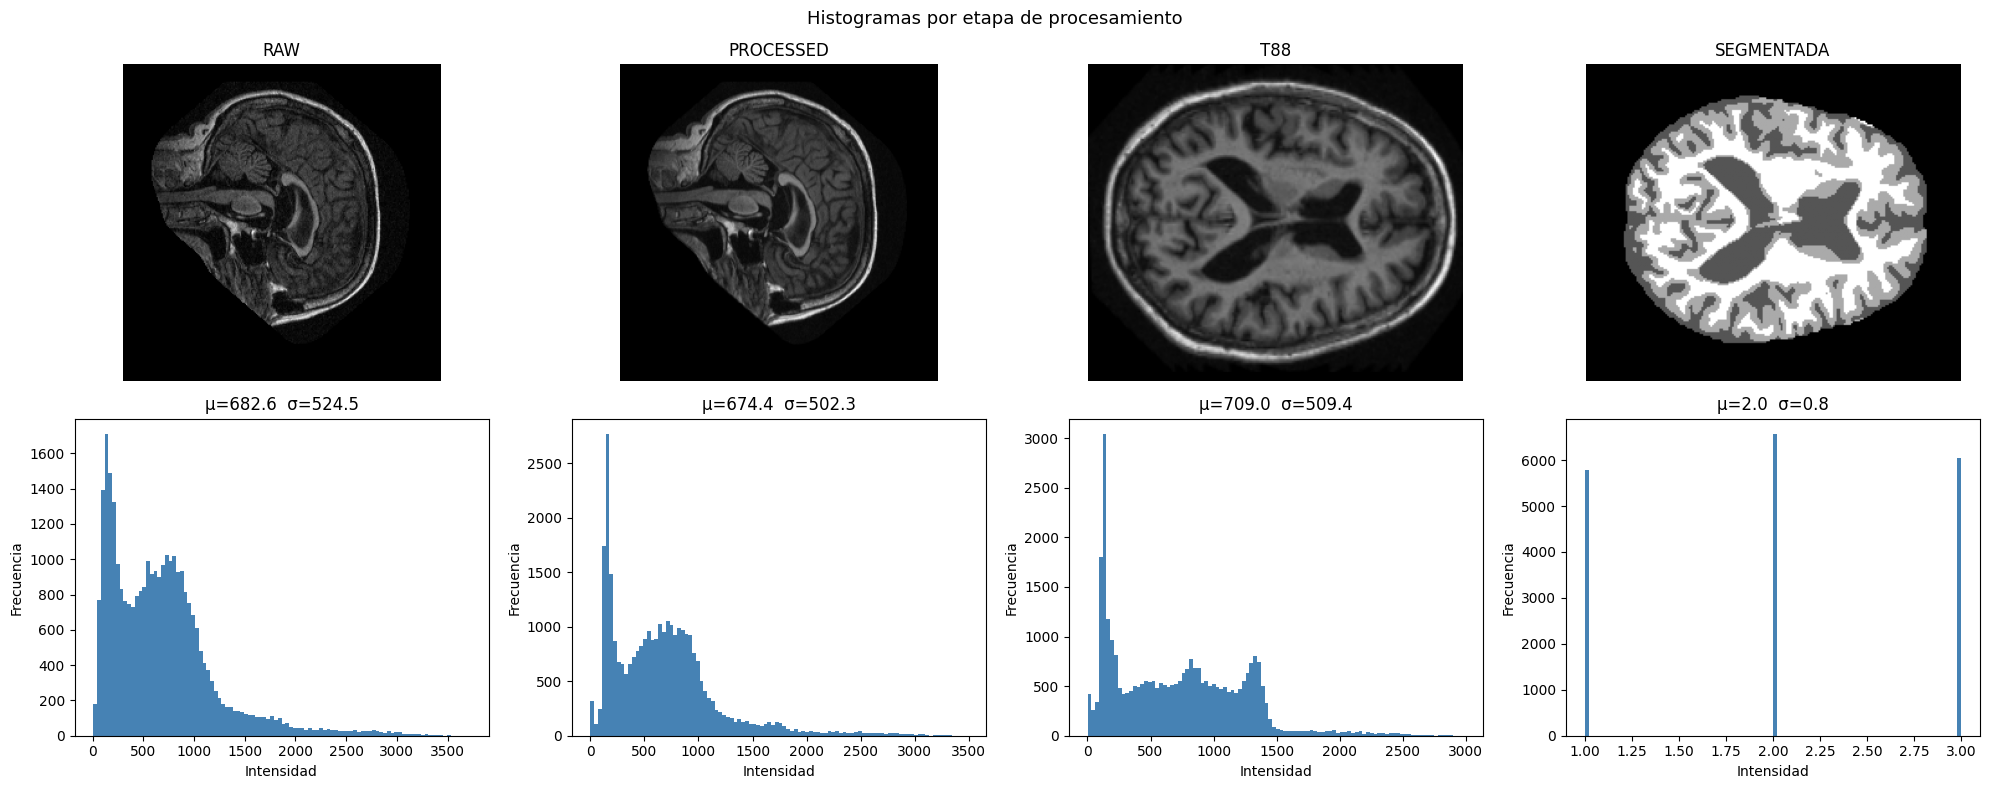

In [ ]:
from scipy.stats import skew, kurtosis

BASE = os.path.join(DATASET_ROOT, 'OAS1_0001_MR1')

paths = {'RAW': os.path.join(BASE, 'RAW', 'OAS1_0001_MR1_mpr-1_anon.hdr'), 'PROCESSED':  os.path.join(BASE, 'PROCESSED', 'MPRAGE', 'SUBJ_111', 'OAS1_0001_MR1_mpr_n4_anon_sbj_111.hdr'), 'T88':        os.path.join(BASE, 'PROCESSED', 'MPRAGE', 'T88_111', 'OAS1_0001_MR1_mpr_n4_anon_111_t88_gfc.hdr'), 'SEGMENTADA': os.path.join(BASE, 'FSL_SEG', 'OAS1_0001_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg.hdr')}
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Histogramas por etapa de procesamiento', fontsize=13)

for col, (titulo, path) in enumerate(paths.items()):
    d = nib.load(path).get_fdata()
    slc = d[:, :, d.shape[2]//2].flatten()
    slc_no_zeros = slc[slc > 0]   
    axes[0, col].imshow(d[:, :, d.shape[2]//2], cmap='gray')
    axes[0, col].set_title(titulo); axes[0, col].axis('off')
    axes[1, col].hist(slc_no_zeros, bins=100, color='steelblue', edgecolor='none')
    axes[1, col].set_title(f'μ={np.mean(slc_no_zeros):.1f}  σ={np.std(slc_no_zeros):.1f}')
    axes[1, col].set_xlabel('Intensidad'); axes[1, col].set_ylabel('Frecuencia')

plt.tight_layout(); plt.show()

Se analizaron los histogramas de intensidad del sujeto OAS1_0001 en sus cuatro versiones disponibles: RAW, PROCESSED, T88 y SEGMENTADA, tomando el slice axial central de cada volumen y excluyendo los píxeles de fondo. Para las versiones RAW y PROCESSED es posible observar un histograma con una distribución asimétrica positiva, lo cual es esperado en este tipo de imágenes, ya que la mayoría de sus píxeles corresponden a tejidos de intensidad media-baja (materia gris) y una minoría corresponde a tejidos más brillantes (materia blanca). Para la versión T88 se obtiene un histograma similar al anterior, pero con una distribución más uniforme, resultado del registro al espacio estándar de Talairach. Por último, la versión SEGMENTADA presenta un histograma discreto con tres valores posibles: 1 = materia gris, 2 = materia blanca, 3 = LCR (líquido cefalorraquídeo).

### 3.2 Estadísticas descriptivas por sujeto

In [52]:
all_hdrs = sorted(glob.glob(
    os.path.join(DATASET_ROOT, '**', 'RAW', '*mpr-1_anon.hdr'), recursive=True
))

print(f"Total de sujetos encontrados: {len(all_hdrs)}")

registros = []
for path in all_hdrs:
    partes = path.replace('\\', '/').split('/')
    sujeto = next((p for p in partes if p.startswith('OAS1_')), 'desconocido')    
    img_ras = nib.as_closest_canonical(nib.load(path))
    d = img_ras.get_fdata().squeeze()   
    px = d[d > 0].ravel()  # píxeles de tejido (excluir fondo) para estadísticas
    
    registros.append({
        'Sujeto':    sujeto,
        'Shape':     d.shape,
        'Min':       round(d.min(), 1),
        'Max':       round(d.max(), 1),
        'Media':     round(np.mean(px), 1),
        'StdDev':    round(np.std(px), 1),
        'Skewness':  round(skew(px), 3),
        'Kurtosis':  round(kurtosis(px), 3)
    })

df = pd.DataFrame(registros)
print(df.to_string(index=False))

Total de sujetos encontrados: 39
       Sujeto           Shape  Min    Max  Media  StdDev  Skewness  Kurtosis
OAS1_0001_MR1 (256, 256, 128)  0.0 4095.0  807.2   674.7     1.184     1.395
OAS1_0002_MR1 (256, 256, 128)  0.0 4095.0  892.5   711.3     1.019     0.817
OAS1_0003_MR1 (256, 256, 128)  0.0 4095.0  852.6   705.8     1.077     0.933
OAS1_0004_MR1 (256, 256, 128)  0.0 4095.0  779.7   616.0     1.020     1.051
OAS1_0006_MR1 (256, 256, 128)  0.0 4095.0  776.3   543.2     0.731     0.352
OAS1_0006_MR1 (256, 256, 128)  0.0 4095.0  797.8   687.0     1.243     1.675
OAS1_0007_MR1 (256, 256, 128)  0.0 4095.0  836.2   603.7     0.766     0.448
OAS1_0009_MR1 (256, 256, 128)  0.0 4095.0  781.8   648.0     1.138     1.345
OAS1_0010_MR1 (256, 256, 128)  0.0 4095.0  846.3   638.7     1.023     0.957
OAS1_0011_MR1 (256, 256, 128)  0.0 4095.0  801.5   686.5     1.182     1.243
OAS1_0012_MR1 (256, 256, 128)  0.0  408.0   75.3    52.9     0.775     0.428
OAS1_0013_MR1 (256, 256, 128)  0.0 4095.0  

Se procesaron los 39 sujetos disponibles en el disco 1 del dataset OASIS, 
todos con dimensiones consistentes de 256 × 256 × 128 vóxeles y rango de 
intensidades de 0 a 4095. Para cada uno se calcularon las siguientes estadisticas de los pixeles de tejido excluyendo su fondo: media, desviación 
estándar, asimetría (skewness) y curtosis (kurtosis). La media de intensidades 
varía entre sujetos en el rango aproximado de 42 a 1009, reflejando diferencias en el brillo global de cada adquisición. La asimetría es positiva en todos los casos (valores entre 0.7 y 1.3), confirmando la distribución característica de MRI T1 con cola hacia intensidades altas. Se destacan dos sujetos atipicos (OAS1_0012 y OAS1_0019) con valores maximos fuera de lo comun, lo que sugiere posibles diferencias en los parametros de adquisicion o normzalicion.

### 3.3 Homogeneidad del dataset

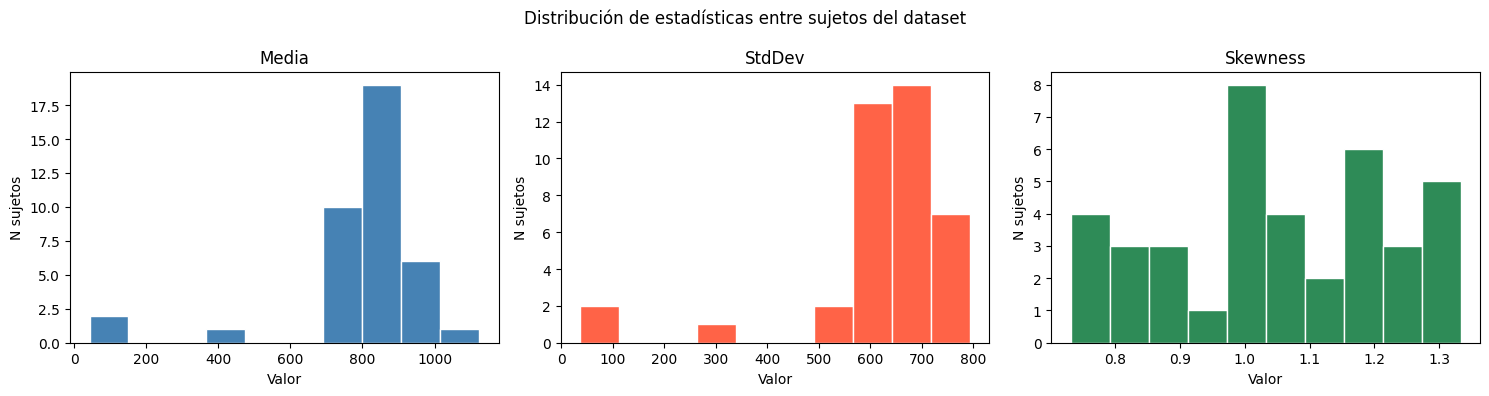

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribución de estadísticas entre sujetos del dataset')

for ax, col, color in zip(axes, ['Media', 'StdDev', 'Skewness'], ['steelblue','tomato','seagreen']):
    ax.hist(df[col], bins=10, color=color, edgecolor='white')
    ax.set_title(col); ax.set_xlabel('Valor'); ax.set_ylabel('N sujetos')


plt.tight_layout(); plt.show()

Ahora se evalua la homogeneidad del dataset, se analizó la distribución 
de tres estadísticas clave a través de los 39 sujetos disponibles en el disco 1. En cuanto a la media de intensidades, la mayoría de los sujetos se concentra en el rango de 800 a 900 unidades de intensidad, con algunos casos atípicos de valores muy bajos (cercanos a 0-200) que corresponden a los sujetos con rango dinámico reducido identificados anteriormente. La desviación estándar se agrupa predominantemente entre 600 y 700, lo que indica que la variabilidad interna de las imágenes es consistente entre sujetos y refleja un contraste similar entre tejidos en la mayoría de los casos. La asimetría (skewness) presenta valores entre 0.7 y 1.3 en todos los sujetos, con una concentración alrededor de 1.0, confirmando que el histograma de intensidades de las imágenes MRI T1 del dataset tiene una distribución asimétricamente positiva de forma consistente. 